In [ ]:
import os
os.chdir("../")

In [ ]:
import os
# Set the huggingface mirror and cache path
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com" # for Chinese
os.environ["HF_HOME"] = "./model_checkpoint/hf_cache"


from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info

import torch
from torch import nn
import torchvision.transforms.functional as TF

import cv2
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from interpretation.efficient_attribution import EfficientMLLMSubModularExplanationVision

from utils import SubRegionDivision
from visualization.visualization import visualization_mllm, visualization_mllm_with_object

In [33]:
def imshow(img):
    """
    Visualizing images inside jupyter notebook
    """
    plt.axis('off')
    if len(img.shape)==3:
        img = img[:,:,::-1] 	# transform image to rgb
    else:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    plt.imshow(img)
    plt.show()

In [ ]:
class QwenVLAdaptor(torch.nn.Module):
    def __init__(self, 
                 model,
                 processor,
                 device = "cuda"):
        super().__init__()
        self.model = model
        self.device = device
        self.softmax = nn.Softmax(dim=-1)
        
        self.processor = processor
        
        self.generated_ids = None
        
        # The position of the token that needs to be explained in the newly generated content (include all tokens)
        self.target_token_position = None
        self.selected_interpretation_token_word_id = None
    
    def forward(self, video):
        """_summary_

        Args:
            image: PIL format
        """
        img = []
        for image in video:
            if isinstance(image, torch.Tensor):
                if image.shape[-1] == 3:
                    image_tensor = image[..., [2, 1, 0]]  # BGR → RGB
                    image_tensor = image_tensor.permute(2, 0, 1)
                    image_tensor = image_tensor.clamp(0, 255).byte()
                    image = TF.to_pil_image(image_tensor)
            img.append(image)
                
        info = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "video",
                        "video": img,
                    },
                ],},
            ]
        
        # Preparation for inference
        text = self.processor.apply_chat_template(
            info, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(info)
        
        inputs = self.processor(
            text=[text],
            videos=video_inputs,    # 这里可以多个
            padding=True,
            return_tensors="pt",
        )
        self.generated_ids = self.generated_ids[:max(self.target_token_position)]   #bug
        inputs['input_ids'] = self.generated_ids
        inputs['attention_mask'] = torch.ones_like(self.generated_ids)
        inputs = inputs.to(self.model.device)    # dict_keys(['input_ids', 'attention_mask', 'pixel_values', 'image_grid_thw'])
        
        # Forward calculation to get all logits (including the logits of the input part)
        with torch.no_grad():
            outputs = self.model(
                **inputs,
                return_dict=True,
                use_cache=True,
            )
            all_logits = outputs.logits  # [batch_size, seq_len, vocab_size]
        
        if self.generated_ids != None:
            returned_logits = all_logits[:, self.target_token_position - 1] # The reason for the minus 1 is that the generated content is in the previous position
            returned_logits = self.softmax(returned_logits)
            
            if self.selected_interpretation_token_word_id != None:
                self.selected_interpretation_token_word_id = torch.tensor(self.selected_interpretation_token_word_id).to(self.model.device)
                indices = self.selected_interpretation_token_word_id.unsqueeze(0).unsqueeze(-1) # [1, N, 1]
                
                returned_logits = returned_logits.gather(dim=2, index=indices) # [1, N, 1]
                
                returned_logits = returned_logits.squeeze(-1)  # [1, N]
        return returned_logits[0]   # size [N]

In [5]:
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct", torch_dtype="auto", device_map="auto"
)
model.eval()

# default processor
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")
tokenizer = processor.tokenizer

# Encapsulation Qwen
Qwen = QwenVLAdaptor(
    model = model,
    processor = processor
)

Loading checkpoint shards: 100%|██████████| 2/2 [01:07<00:00, 33.93s/it]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [31]:
explainer = EfficientMLLMSubModularExplanationVision(
    Qwen,
    search_scope = 8,
    pending_samples = 4,
    update_step = 10
)

cuda


## Load the video

In [7]:
video_path = "examples/frames"

video_input = []
image_list = os.listdir(video_path)
for image_name in image_list:
    image_path = os.path.join(video_path, image_name)
    video_input.append(Image.open(image_path))

text_prompt = "Describe the image in one factual English sentence of no more than 20 words. Do not include information that is not clearly visible."

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "video",
                "video": video_input,
            },
            {"type": "text", "text": text_prompt},
        ],
    }
]

In [10]:
# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)

# Data proccessing
inputs = processor(
    text=[text],
    videos=video_inputs,    # 这里可以多个
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)    # dict_keys(['input_ids', 'attention_mask', 'pixel_values', 'image_grid_thw'])

# Inference: Generation of the output
with torch.no_grad():
    generated_ids = model.generate(
        **inputs, 
        do_sample=False,      # Disable sampling and use greedy search instead
        num_beams=1,          # Set to 1 to ensure greedy search instead of beam search.
        max_new_tokens=128)
    generated_ids_trimmed = [   # 去掉图像和prompt的文本
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
output_words = processor.batch_decode(
    generated_ids_trimmed[0], skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)
print(output_words)
print(generated_ids_trimmed)

['A man wearing a white shirt and blue shorts is standing in front of a brown couch.']
['A', ' man', ' wearing', ' a', ' white', ' shirt', ' and', ' blue', ' shorts', ' is', ' standing', ' in', ' front', ' of', ' a', ' brown', ' couch', '.', '']
[tensor([    32,    883,  12233,    264,   4158,  15478,    323,   6303,  35776,
           374,  11259,    304,   4065,    315,    264,  13876,  26148,     13,
        151645], device='cuda:0')]


## 😮 Sentence-level Interpretation

In [11]:
# Select all words to explain
selected_interpretation_token_id = [i for i in range(len(output_words))]
selected_interpretation_token_word_id = generated_ids_trimmed[0].tolist()

In [ ]:
## Equip the model with the generated ids and the target token position to be explained
Qwen.generated_ids = generated_ids
Qwen.target_token_position = np.array(selected_interpretation_token_id) + len(inputs['input_ids'][0])
Qwen.selected_interpretation_token_word_id = selected_interpretation_token_word_id

In [20]:
def load_frames_sorted(video_path):
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    names = [n for n in os.listdir(video_path) if n.lower().endswith(exts)]
    names.sort()
    frames = []
    for n in names:
        img = cv2.imread(os.path.join(video_path, n))
        if img is not None:
            frames.append(img)
    return frames, names

def build_V_set_5x5_keep_channel(frames):
    """
    Returns:
      V_set: list of length 25N
             each element is (N, H, W, 1) binary mask
    """
    N = len(frames)
    H, W = frames[0].shape[:2]

    rows = np.linspace(0, H, 6, dtype=int)
    cols = np.linspace(0, W, 6, dtype=int)

    V_set = []
    for t in range(N):
        for r in range(5):
            for c in range(5):
                y0, y1 = rows[r], rows[r + 1]
                x0, x1 = cols[c], cols[c + 1]

                # 多保留一个 1 通道
                mask = np.zeros((N, H, W, 1), dtype=np.uint8)
                mask[t, y0:y1, x0:x1, 0] = 1
                V_set.append(mask)

    # sanity check：每帧 25 块相加 == 全 1
    for t in range(N):
        s = np.zeros((H, W), dtype=np.uint16)
        base = t * 25
        for k in range(25):
            s += V_set[base + k][t, :, :, 0]
        assert np.all(s == 1), f"Partition failed at frame {t}"

    return V_set

# ----------------
# usage
# ----------------
video_path = "examples/frames"
frames, _ = load_frames_sorted(video_path)
V_set = build_V_set_5x5_keep_channel(frames)

In [32]:
## Begin to explain
S_set, saved_json_file = explainer(image, V_set)
saved_json_file["selected_interpretation_token_id"] = selected_interpretation_token_id
saved_json_file["selected_interpretation_token_word_id"] = selected_interpretation_token_word_id
saved_json_file["words"] = output_words

ValueError: Image features and image tokens do not match: tokens: 0, features 2160

In [76]:
S_set = np.load("video.npy")
with open("video.json", 'r', encoding='utf-8') as f:
    saved_json_file = json.load(f)
saved_json_file["smdl_score"] = (np.array(saved_json_file["insertion_score"]) + 1 - np.array(saved_json_file["deletion_score"])).tolist()


In [5]:
from visualization.visualization import *

In [85]:
def add_value_(S_set, json_file):
    single_mask = np.zeros_like(S_set[0])
    single_mask = single_mask.astype(np.float16)
    
    value_list_1 = np.array(json_file["smdl_score"])
    
    # value_list_2 = np.array(
    #     [1 - np.mean(json_file["org_score"]) + np.mean(json_file["baseline_score"])] + json_file["smdl_score"][:-1]
    # )
    value_list_2 = np.array(
        [np.mean(1 - np.array(json_file["org_score"]) + np.array(json_file["baseline_score"]))] + json_file["smdl_score"][:-1]
    )
    
    # value_list = np.exp((value_list_1 - value_list_2)/1)
    value_list = value_list_1 - value_list_2
    
    values = []
    value = 0
    i = 0
    for smdl_single_mask, smdl_value in zip(S_set, value_list):
        value = value - abs(smdl_value)
        single_mask[smdl_single_mask==1] = value
        values.append(value)
        i+=1
    attribution_map = single_mask - single_mask.min()
    attribution_map = attribution_map / attribution_map.max()
    
    return attribution_map, np.array(values)

def gen_cam(image_path, mask):
    """
    Generate heatmap
        :param image: [H,W,C]
        :param mask: [H,W],range 0-1
        :return: tuple(cam,heatmap)
    """
    # Read image
    w = mask.shape[1]
    h = mask.shape[0]
    image = cv2.resize(cv2.imread(image_path), (w,h))
    # mask->heatmap
    mask = cv2.resize(mask, (int(w/40),int(h/40)))
    mask = cv2.resize(mask, (w,h))
    heatmap = cv2.applyColorMap(np.uint8(mask), cv2.COLORMAP_VIRIDIS)  # cv2.COLORMAP_COOL
    heatmap = np.float32(heatmap)

    # merge heatmap to original image
    cam = 0.5*heatmap + 0.5*np.float32(image)
    return cam.astype(np.uint8), (heatmap).astype(np.uint8)


In [86]:
attribution_map, _ = add_value_(S_set, saved_json_file)
attribution_map = norm_image(attribution_map[:, :,:,0])

In [87]:
video_path = "examples/frames"

video_input = []
image_list = os.listdir(video_path)
for image_name in image_list:
    image_path = os.path.join(video_path, image_name)
    video_input.append(image_path)

In [88]:
cams = []
for attribution_map_, image_path in zip(attribution_map, video_input):
    cam, _ = gen_cam(image_path, attribution_map_)
    cams.append(cam)

In [89]:
text = saved_json_file.get("words", None)
word_heatmap_scores = get_word_saliency(saved_json_file)

In [90]:
for i, cam in enumerate(cams):
    visualize_explanation(cam, text, word_heatmap_scores)
    
    plt.savefig("video_{}.png".format(i), bbox_inches='tight', pad_inches=0)
    plt.close()

In [31]:
attribution_map.shape

(5, 504, 336)

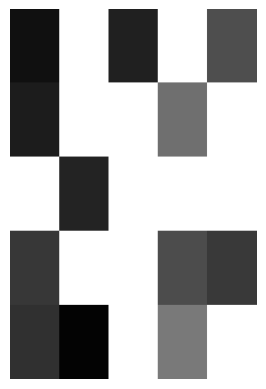

In [60]:
imshow(attribution_map[0])

In [55]:
attribution_map[0].max()

np.uint8(255)

In [56]:
attribution_map[1].max()

np.uint8(255)

In [69]:
S_set[0][4].max()

np.uint8(1)